## Analysis of session4_train_2018.mat 

In [2]:
import scipy.io as scio
from scipy.signal import welch, get_window
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from prettytable import PrettyTable
import matplotlib.pyplot as plot

# please enter the address of input file "session4_train_2018.mat"
path = r'session4_train_2018.mat'  # PATH TO THE FILE
data = scio.loadmat(path)

In [3]:
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Fri Oct 31 15:13:57 2014',
 '__version__': '1.0',
 '__globals__': [],
 'EEG': array([[(array([[445.6166  , 438.19293 , 410.8425  , ...,  77.167274,  56.849815,
                  63.882782]], dtype=float32), array([[62]], dtype=uint8), array([[124]], dtype=uint8), array(['s'], dtype='<U1'), array([[256]], dtype=uint16))]],
       dtype=[('data', 'O'), ('seizureStart', 'O'), ('seizureEnd', 'O'), ('timeUnits', 'O'), ('srate', 'O')])}

In [4]:
raw = data['EEG'][0][0][0][0]   # EXPERIMENT WITH THIS
raw

array([445.6166  , 438.19293 , 410.8425  , ...,  77.167274,  56.849815,
        63.882782], dtype=float32)

/Users/pgmenon/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Text(0, 0.5, 'Amplitude')

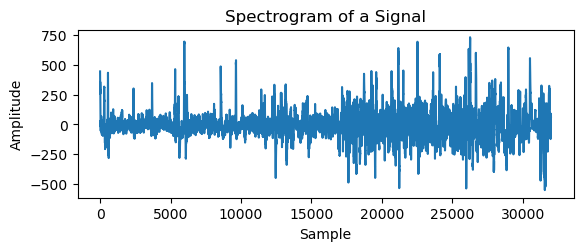

In [5]:
import pandas as pd

plot.subplot(211)
plot.title('Spectrogram of a Signal')

signal = pd.DataFrame(raw)
DF = pd.DataFrame({
    'S': signal.iloc[:,0]
})
plot.plot(DF.S)
plot.xlabel('Sample')
plot.ylabel('Amplitude')


In [6]:
samplingFrequency = data['EEG'][0][0][4][0][0]  #- fix this path!

samplingFrequency

256

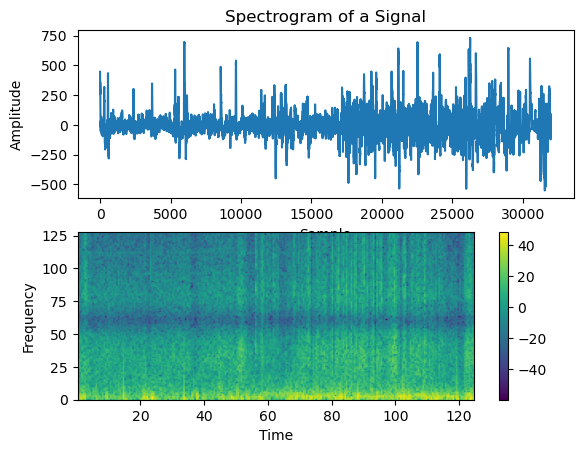

In [15]:
plot.subplot(211)
plot.title('Spectrogram of a Signal')

signal = pd.DataFrame(raw)
DF = pd.DataFrame({
    'S': signal.iloc[:,0]
})
plot.plot(DF.S)
plot.xlabel('Sample')
plot.ylabel('Amplitude')

# Compute and plot a spectrogram of data in x. Data are split into NFFT length segments and the spectrum of each section is computed.
# The windowing function window is applied to each segment, and the amount of overlap of each segment is specified with noverlap. The spectrogram is plotted as a colormap (using imshow).
plot.subplot(212)
# Changing noverlap to be an integer using integer division //
plot.specgram(DF.S,Fs=samplingFrequency,NFFT=samplingFrequency, noverlap=(samplingFrequency//2))
plot.xlabel('Time')
plot.ylabel('Frequency')

plot.colorbar()
plot.show()

## Explore the spectrogram and engineer features

In [17]:
# given DF , with a single column 'S' , and samplingFrequency, create a time axis in seconds for the signal
def time_axis(DF, samplingFrequency):
    return np.arange(0, len(DF)/samplingFrequency, 1/samplingFrequency)

DF['time'] = time_axis(DF, samplingFrequency)

DF.head()


,S,time
0,445.616608,0.000000
1,438.192932,0.003906
2,410.842499,0.007812
3,387.008545,0.011719
4,374.114777,0.015625


In [18]:
# Split the time series into windows of size NFFT=samplingFrequency, with 50% overlap i.e. (samplingFrequency//2)). Do this by creating a column with the window number for each row of the signal.

import pandas as pd

def window_number(DF, samplingFrequency):
    window_size = samplingFrequency
    step_size = samplingFrequency // 2
    num_windows = (len(DF) - step_size) // step_size + 1
    
    windows = []
    for i in range(len(DF)):
        row_windows = []
        for j in range(num_windows):
            start_idx = j * step_size
            end_idx = start_idx + window_size
            if start_idx <= i < end_idx:
                row_windows.append(j)
        windows.append(row_windows)
    
    return windows

DF['window'] = window_number(DF, samplingFrequency)


In [22]:
# view the rows 256/2 to 256*2
# display all rows when printing in pandas
pd.set_option('display.max_rows', None)
DF.iloc[256//2-10:256*2]

,S,time,window
118,-15.824176,0.460938,[0]
119,-30.280830,0.464844,[0]
120,-64.664223,0.468750,[0]
121,-73.260071,0.472656,[0]
122,-61.929180,0.476562,[0]
123,-49.816849,0.480469,[0]
124,-30.671551,0.484375,[0]
125,-12.698413,0.488281,[0]
126,-5.274725,0.492188,[0]
127,-38.095238,0.496094,[0]


In [24]:
# superimpose all the windows in a common time axis, since they are all of the same length in a plotly plot

import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Assuming DF is your DataFrame and samplingFrequency is defined
def window_number(DF, samplingFrequency):
    window_size = samplingFrequency # window size is the same as NFFT
    step_size = samplingFrequency // 2  # 50% overlap
    num_windows = (len(DF) - step_size) // step_size + 1
    
    windows = []
    for i in range(len(DF)):
        row_windows = []
        for j in range(num_windows):
            start_idx = j * step_size
            end_idx = start_idx + window_size
            if start_idx <= i < end_idx:
                row_windows.append(j)
        windows.append(row_windows)
    
    return windows

DF['window'] = window_number(DF, samplingFrequency)

# Extract windows
window_size = samplingFrequency
step_size = samplingFrequency // 2
num_windows = (len(DF) - step_size) // step_size + 1

windows = []
for i in range(num_windows):
    start_idx = i * step_size
    end_idx = start_idx + window_size
    windows.append(DF.iloc[start_idx:end_idx])

# Create a common time axis
time_axis = np.arange(window_size) / samplingFrequency

# Plot using Plotly
fig = go.Figure()

for i, window in enumerate(windows):
    fig.add_trace(go.Scatter(x=time_axis, y=window['S'], mode='lines', name=f'Window {i}'))

fig.update_layout(title='Superimposed Windows on Common Time Axis',
                  xaxis_title='Time (s)',
                  yaxis_title='Signal',
                  showlegend=True)

fig.show()



## Lets engineer some frequency based features now

### Example of a spectrogram and what it means to compute power 

Text(0, 0.5, 'Amplitude')

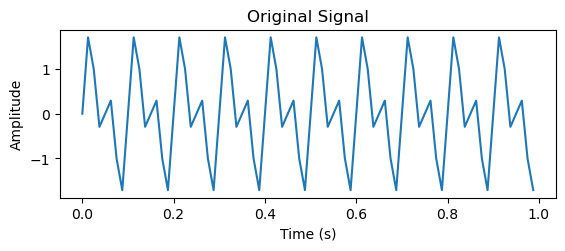

In [33]:
import numpy as np
import plotly.graph_objects as go
from scipy.signal import welch, get_window

def extract_features(segment, fs):
    window = get_window('hamming', fs)
    nfft = fs
    freq, psd = welch(segment, window=window, fs=fs, nfft=nfft)
    total_energy = np.trapz(psd, freq)
    
    delta_power = np.trapz(psd[(freq >= 1) & (freq < 4)]) / total_energy
    theta_power = np.trapz(psd[(freq >= 4) & (freq < 7)]) / total_energy
    alpha_power = np.trapz(psd[(freq >= 7) & (freq < 12)]) / total_energy
    beta_power = np.trapz(psd[(freq >= 12) & (freq < 20)]) / total_energy
    
    return freq, psd, [delta_power, theta_power, alpha_power, beta_power]

# Generate a sample signal
fs = 8  # Sampling frequency
t = np.linspace(0, 1, fs * 10, endpoint=False)  # 10 seconds of data
signal = np.sin(2 * np.pi * 10 * t) + np.sin(2 * np.pi * 20 * t)  # Example signal with 10 Hz and 20 Hz components

# Extract features and get PSD
freq, psd, features = extract_features(signal, fs)

# Create the plot
fig = go.Figure()

# Plot the PSD
fig.add_trace(go.Scatter(x=freq, y=psd, mode='lines', name='PSD'))

# Highlight the frequency bands
bands = {
    'Delta (1-4 Hz)': (1, 4),
    'Theta (4-7 Hz)': (4, 7),
    'Alpha (7-12 Hz)': (7, 12),
    'Beta (12-20 Hz)': (12, 20)
}

for band_name, (band_start, band_end) in bands.items():
    band_mask = (freq >= band_start) & (freq < band_end)
    fig.add_trace(go.Scatter(
        x=freq[band_mask], y=psd[band_mask], mode='lines', name=band_name
    ))
    
# Update layout
fig.update_layout(
    title='Power Spectral Density with Frequency Bands',
    xaxis_title='Frequency (Hz)',
    yaxis_title='Power Spectral Density (PSD)',
    legend_title='Frequency Bands'
)

# Show the plot
fig.show()



# plot the original signal in a new plot
plot.subplot(211)
plot.title('Original Signal')
plot.plot(t, signal)
plot.xlabel('Time (s)')
plot.ylabel('Amplitude')


### Lets do the same for our original signal (EEG)

In [34]:
import numpy as np
import pandas as pd
from scipy.signal import welch, get_window
from sklearn.preprocessing import normalize

def extract_features(segment, fs):
    window = get_window('hamming', fs)
    nfft = fs
    freq, psd = welch(segment, window=window, fs=fs, nfft=nfft)
    total_energy = np.trapz(psd, freq)
    
    delta_power = np.trapz(psd[(freq >= 1) & (freq < 4)]) / total_energy
    theta_power = np.trapz(psd[(freq >= 4) & (freq < 7)]) / total_energy
    alpha_power = np.trapz(psd[(freq >= 7) & (freq < 12)]) / total_energy
    beta_power = np.trapz(psd[(freq >= 12) & (freq < 20)]) / total_energy
    
    return [delta_power, theta_power, alpha_power, beta_power]

def process_segments(raw, fs, label, start, end, segment_duration):
    segments = []
    step = fs * segment_duration
    for i in range(start, end):
        segment = raw[i * step:(i + 2) * step]
        features = extract_features(segment, fs)
        features.append(label)
        segments.append(features)
    return segments

# Assuming `data` and `raw` are defined
fs = samplingFrequency
segment_duration = 1  # Duration of each segment in seconds

# Calculate the number of segments
total_segments = len(raw) // (fs * segment_duration)
half_segments = total_segments // 2

##  Based on knowledge of the ground truth of seizure labels in the dataset, we can split the segments into seizure and non-seizure segments.
# Process non-seizure segments
non_seizure_segments = process_segments(raw, fs, label=0, start=0, end=half_segments, segment_duration=segment_duration)

# Process seizure segments
seizure_segments = process_segments(raw, fs, label=1, start=half_segments, end=total_segments, segment_duration=segment_duration)

# Combine segments
all_segments = non_seizure_segments + seizure_segments

# Convert to DataFrame
segments_df = pd.DataFrame(all_segments, columns=['delta', 'theta', 'alpha', 'beta', 'seizure'])

# Normalize the signal data (not the ground truth labels!)
segments_df[['delta', 'theta', 'alpha', 'beta']] = normalize(segments_df[['delta', 'theta', 'alpha', 'beta']])

# Convert seizure column to category
segments_df['seizure'] = segments_df['seizure'].astype('category')

# Display DataFrame info and value counts
print(segments_df.info(verbose=True))
print(segments_df['seizure'].value_counts())

# Display the first few rows
segments_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   delta    125 non-null    float64 
 1   theta    125 non-null    float64 
 2   alpha    125 non-null    float64 
 3   beta     125 non-null    float64 
 4   seizure  125 non-null    category
dtypes: category(1), float64(4)
memory usage: 4.3 KB
None
seizure
1    63
0    62
Name: count, dtype: int64


,delta,theta,alpha,beta,seizure
0,0.995975,0.075758,0.043777,0.019427,0
1,0.992658,0.111096,0.044879,0.016525,0
2,0.993037,0.108308,0.040143,0.023155,0
3,0.763365,0.570391,0.243744,0.180323,0
4,0.864663,0.453227,0.206527,0.065492,0


In [35]:
segments_df.to_csv('segments_fs_width_50pct_overlap_DTAB_GT.csv', index=False)

## Now lets do some EDA on segments_df to compare seizure and non-seizure data for each feature

In [36]:
# make plotly boxplots grouped by seizure column
import plotly.express as px

fig = px.box(segments_df, x='seizure', y='delta', points='all', title='Delta Power Distribution by Seizure Status')
fig.show()

fig = px.box(segments_df, x='seizure', y='theta', points='all', title='Theta Power Distribution by Seizure Status')
fig.show()

fig = px.box(segments_df, x='seizure', y='alpha', points='all', title='Alpha Power Distribution by Seizure Status')
fig.show()

fig = px.box(segments_df, x='seizure', y='beta', points='all', title='Beta Power Distribution by Seizure Status')
fig.show()

In [38]:
# Lets get non-parametric Mann-Whitney U test results for each feature comparing seizure and non-seizure segments

from scipy.stats import mannwhitneyu
import pandas as pd

def mannwhitneyu_test(df, feature):
    seizure = df[df['seizure'] == 1][feature]
    non_seizure = df[df['seizure'] == 0][feature]
    
    if len(seizure) == 0 or len(non_seizure) == 0:
        raise ValueError(f"One of the groups for feature '{feature}' has no observations.")
    
    stat, p = mannwhitneyu(seizure, non_seizure)
    return stat, p

features = ['delta', 'theta', 'alpha', 'beta']
results = {feature: mannwhitneyu_test(segments_df, feature) for feature in features}

results_df = pd.DataFrame(results, index=['statistic', 'p-value'])
results_df

,delta,theta,alpha,beta
statistic,2390.000000,1686.000000,984.000000,9.190000e+02
p-value,0.031132,0.188194,0.000002,3.338100e-07


In [39]:
# Lets get unpaired t-test results for each feature comparing seizure and non-seizure segments

from scipy.stats import ttest_ind
import pandas as pd

def ttest_ind_test(df, feature):
    seizure = df[df['seizure'] == 1][feature]
    non_seizure = df[df['seizure'] == 0][feature]
    
    if len(seizure) == 0 or len(non_seizure) == 0:
        raise ValueError(f"One of the groups for feature '{feature}' has no observations.")
    
    stat, p = ttest_ind(seizure, non_seizure, equal_var=False)
    return stat, p

features = ['delta', 'theta', 'alpha', 'beta']
results = {feature: ttest_ind_test(segments_df, feature) for feature in features}

results_df = pd.DataFrame(results, index=['statistic', 'p-value'])
results_df

,delta,theta,alpha,beta
statistic,1.853863,-1.307449,-4.907429,-5.105461
p-value,0.066687,0.193591,0.000005,0.000003


# Lets build a model to classify Seizure state


In [2]:
# import h2o and initialize a local H2O cluster
import h2o
h2o.init(max_mem_size='2G')

# remove all
h2o.remove_all()

Checking whether there is an H2O instance running at http://localhost:54321 . connected.


H2O_cluster_uptime:,13 mins 08 secs
H2O_cluster_timezone:,America/New_York
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.36.1.3
H2O_cluster_version_age:,"2 years, 6 months and 22 days !!!"
H2O_cluster_name:,H2O_from_python_pgmenon_t7pjfm
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.938 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


## Lets load XRT_2_AutoML_3_20250130_183051 model and run it for predictions


In [4]:
import pandas as pd
segments_df = pd.read_csv('segments_fs_width_50pct_overlap_DTAB_GT.csv')

/Users/pgmenon/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [5]:
XRT_2_AutoML_3_20250130_183051 = h2o.load_model("models_session2018/XRT_2_AutoML_3_20250130_183051")

# run predictions on segments_df
segments_h2o = h2o.H2OFrame(segments_df, destination_frame='all_segments_h2o.hex')

predictions = XRT_2_AutoML_3_20250130_183051.predict(segments_h2o)

predictions_df = predictions.as_data_frame()

predictions_df


/Users/pgmenon/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
drf prediction progress: |███████████████████████████████████████████████████████| (done) 100%


,predict,p0,p1
0,1,0.921053,0.078947
1,1,0.947368,0.052632
2,0,0.973684,0.026316
3,1,0.815789,0.184211
4,0,0.973684,0.026316
...,...,...,...
120,1,0.815789,0.184211
121,1,0.000000,1.000000
122,1,0.000000,1.000000
123,1,0.052632,0.947368


In [16]:
segments_df.head()

,delta,theta,alpha,beta,seizure,prediction,prediction_prob_1,prediction_optimal
0,0.995975,0.075758,0.043777,0.019427,0,1,0.078947,False
1,0.992658,0.111096,0.044879,0.016525,0,1,0.052632,False
2,0.993037,0.108308,0.040143,0.023155,0,0,0.026316,False
3,0.763365,0.570391,0.243744,0.180323,0,1,0.184211,False
4,0.864663,0.453227,0.206527,0.065492,0,0,0.026316,False


In [14]:
segments_df['prediction'] = predictions_df['predict']
segments_df['prediction_optimal'] = predictions_df['p1']>=0.44
segments_df['prediction_prob_1'] = predictions_df['p1']

In [13]:
# use the confusion matrix to calculate the accuracy using sklearn report
from sklearn.metrics import classification_report

print(classification_report(segments_df['seizure'], segments_df['prediction']))

              precision    recall  f1-score   support

           0       1.00      0.27      0.43        62
           1       0.58      1.00      0.74        63

    accuracy                           0.64       125
   macro avg       0.79      0.64      0.58       125
weighted avg       0.79      0.64      0.58       125



In [15]:
# use the confusion matrix to calculate the accuracy using sklearn report
from sklearn.metrics import classification_report

print(classification_report(segments_df['seizure'], segments_df['prediction_optimal']))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89        62
           1       0.92      0.86      0.89        63

    accuracy                           0.89       125
   macro avg       0.89      0.89      0.89       125
weighted avg       0.89      0.89      0.89       125



/Users/pgmenon/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/pgmenon/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


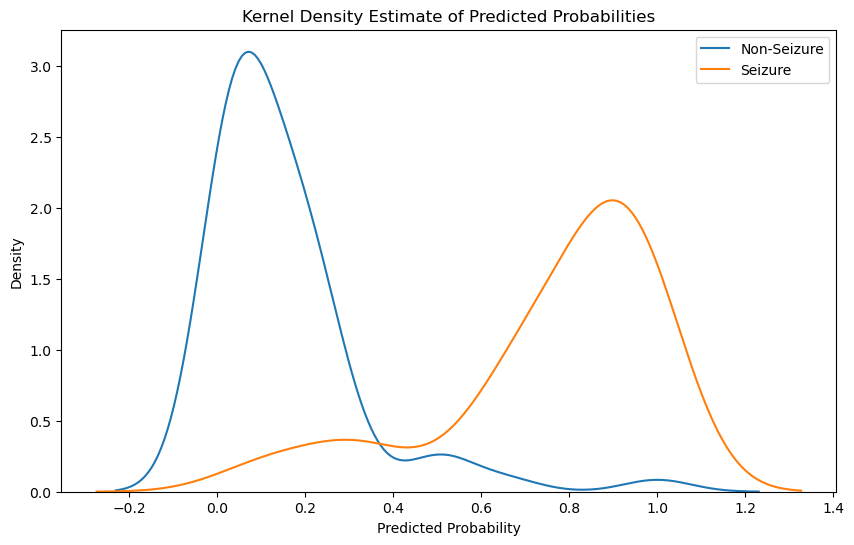

In [17]:
# plot a kernel density estimate of the predicted probabilities for each class
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.kdeplot(segments_df[segments_df['seizure'] == 0]['xprediction_prob_1'], label='Non-Seizure')
sns.kdeplot(segments_df[segments_df['seizure'] == 1]['prediction_prob_1'], label='Seizure')
plt.title('Kernel Density Estimate of Predicted Probabilities')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend()
plt.show()